Drift simulation: California Housing dataset.
 
Splits the dataset by GEOGRAPHY (inland vs coastal latitude), not by the
target variable. This means any shift you see in MedHouseVal is a genuine
downstream CONSEQUENCE of the geographic split - not a tautology created by
filtering on the thing you're then plotting.


Dataset Loaded: 20640 rows, 9 columns
Reference Set (Inland, Lat > 36): (2000, 9)
Current Set (Coastal, Lat <= 36): (2000, 9)


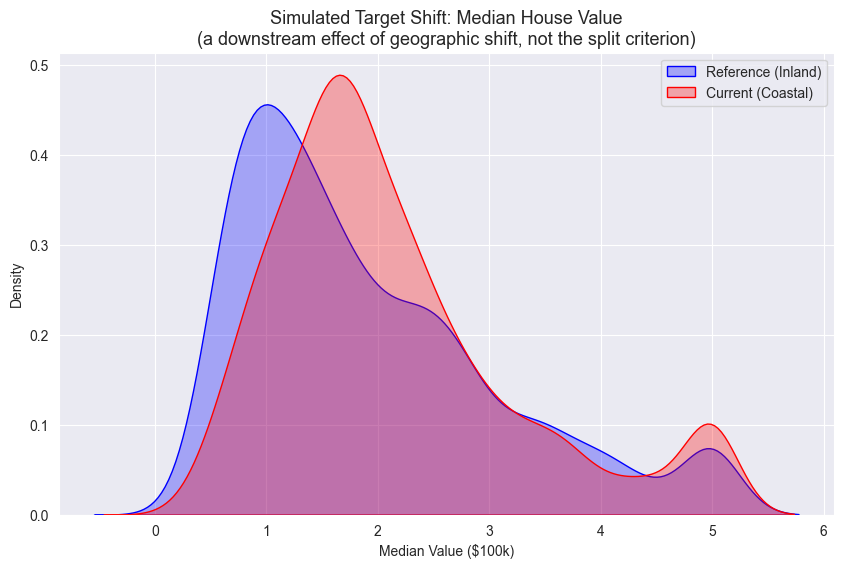

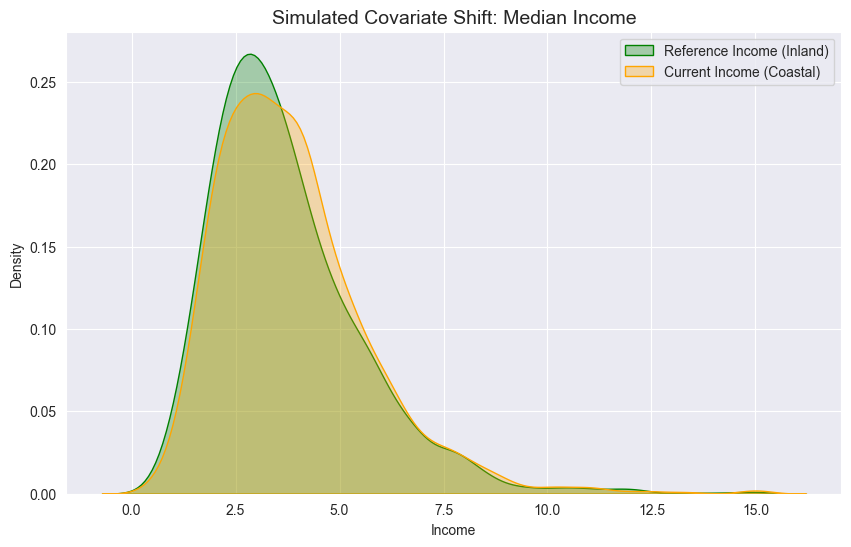

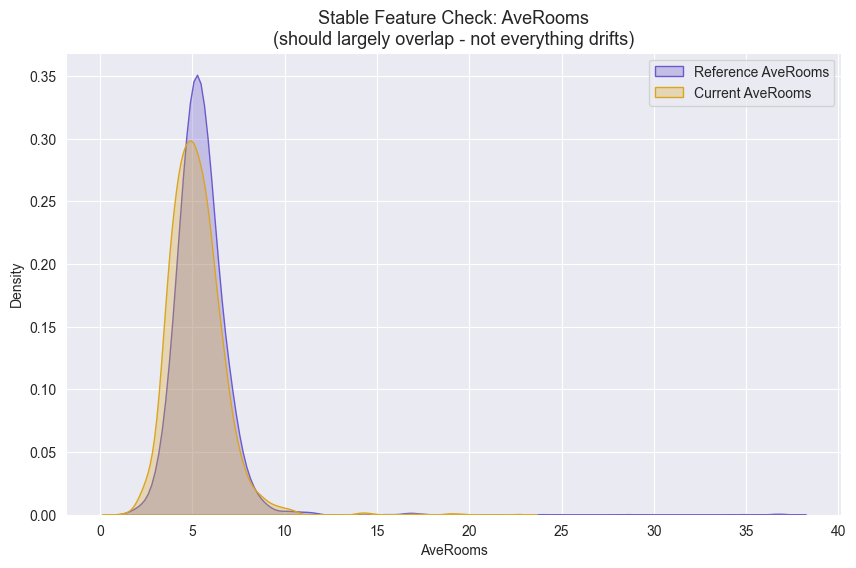

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing


def load_data():
    housing = fetch_california_housing(as_frame=True)
    df = housing.frame
    print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
    return df


def split_by_geography(df, n_samples=2000, random_state=42):
    """
    Reference = inland California (Latitude > 36)
    Current   = coastal California (Latitude <= 36)

    This mirrors a real deployment scenario: a model trained on one region
    gets served against a different region. MedHouseVal is allowed to differ
    as a RESULT of the shift, rather than being the variable we sliced on.
    """
    ref_df = df[df['Latitude'] > 36].sample(n_samples, random_state=random_state)
    curr_df = df[df['Latitude'] <= 36].sample(n_samples, random_state=random_state)

    print(f"Reference Set (Inland, Lat > 36): {ref_df.shape}")
    print(f"Current Set (Coastal, Lat <= 36): {curr_df.shape}")
    return ref_df, curr_df


def plot_target_shift(ref_df, curr_df):
    """Target distribution - a CONSEQUENCE of the geographic shift, not the split criterion."""
    plt.figure(figsize=(10, 6))
    sns.set_style("darkgrid")

    sns.kdeplot(ref_df['MedHouseVal'], label='Reference (Inland)', fill=True, color='blue', alpha=0.3)
    sns.kdeplot(curr_df['MedHouseVal'], label='Current (Coastal)', fill=True, color='red', alpha=0.3)

    plt.title(
        "Simulated Target Shift: Median House Value\n"
        "(a downstream effect of geographic shift, not the split criterion)",
        fontsize=13,
    )
    plt.xlabel("Median Value ($100k)")
    plt.legend()
    plt.show()


def plot_covariate_shift(ref_df, curr_df):
    """Feature drift - genuinely independent of how we split, since we split on geography."""
    plt.figure(figsize=(10, 6))

    sns.kdeplot(ref_df['MedInc'], label='Reference Income (Inland)', fill=True, color='green', alpha=0.3)
    sns.kdeplot(curr_df['MedInc'], label='Current Income (Coastal)', fill=True, color='orange', alpha=0.3)

    plt.title("Simulated Covariate Shift: Median Income", fontsize=14)
    plt.xlabel("Income")
    plt.legend()
    plt.show()


def plot_stable_feature(ref_df, curr_df, column='AveRooms'):
    """
    Sanity check: shows a feature that should NOT shift much between the two
    groups. A real drift story includes features that stay stable - that's
    what makes the ones that DO shift meaningful, rather than everything
    moving because of one shared confound.
    """
    plt.figure(figsize=(10, 6))

    sns.kdeplot(ref_df[column], label=f'Reference {column}', fill=True, color='slateblue', alpha=0.3)
    sns.kdeplot(curr_df[column], label=f'Current {column}', fill=True, color='goldenrod', alpha=0.3)

    plt.title(f"Stable Feature Check: {column}\n(should largely overlap - not everything drifts)", fontsize=13)
    plt.xlabel(column)
    plt.legend()
    plt.show()


def main():
    df = load_data()
    ref_df, curr_df = split_by_geography(df)

    plot_target_shift(ref_df, curr_df)
    plot_covariate_shift(ref_df, curr_df)
    plot_stable_feature(ref_df, curr_df, column='AveRooms')


if __name__ == "__main__":
    main()